# 🏠 Zimbabwe Real Estate Price Prediction System
## Phase 1 — Exploratory Data Analysis

**Dataset:** `property_phase1_engineered.csv`  
**Records:** 2,036 residential listings | **Features:** 41  
**Market:** Zimbabwe (Harare, Bulawayo, Gweru, Mutare, Ruwa, Norton)  
**Scraped:** April 2026

---

### Notebook Structure

| Section | Focus |
|---------|-------|
| 1. Setup & Load | Imports, data loading, quick shape check |
| 2. Missing Values | Heatmap & column-level null audit |
| 3. Price Analysis | Distribution, log-scale, segment breakdown |
| 4. Outlier Analysis | IQR method, boxplots |
| 5. Feature Distributions | Numeric & categorical columns |
| 6. Correlation Matrix | Numeric feature heatmap |
| 7. Segment Analysis | Budget / Mid / Premium / Luxury deep-dive |
| 8. Amenity Analysis | Prevalence, pricing impact |
| 9. Region & Suburb Analysis | Geographic price patterns |
| 10. Key Insights Summary | Findings to carry into Phase 2 |

---
> All charts are saved to `reports/figures/` as PNG (300 dpi).


# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os

warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
PALETTE   = ['#1A1A2E','#16213E','#0F3460','#E94560','#27AE60','#F39C12','#8E44AD','#2980B9']
SEG_COLORS = {'Budget':'#27AE60','Mid':'#2980B9','Premium':'#F39C12','Luxury':'#E94560'}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# ── Output folder ───────────────────────────────────────────────────────────
FIG_DIR = 'reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

def save(name):
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

print('✅ Setup complete.')


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import shap
import warnings
warnings.filterwarnings('ignore')

In [6]:
# ── Load dataset ────────────────────────────────────────────────────────────
DATA_PATH = 'Desktop/Zimbabwe Real Estate Price Prediction System/property_phase1_engineered.csv'
# If running from repo root; adjust path if needed:
import os
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'property_phase1_engineered.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage     : {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'Duplicate rows   : {df.duplicated().sum()}')
print(f'Duplicate URLs   : {df["listing_url"].duplicated().sum()}')
print()
print(df.head(3).T)


Shape            : 2,036 rows × 41 columns
Memory usage     : 1.4 MB
Duplicate rows   : 36
Duplicate URLs   : 36

                                                                     0  \
price                                                        2500000.0   
suburb                                                      Helensvale   
region                                                    Harare North   
house_type                                             4 Bedroom House   
bedrooms                                                           4.0   
bathrooms                                                          4.0   
floor_area                                                      3600.0   
land_size                                                      14000.0   
furnished                                                        False   
payment_terms                                                      NaN   
agent_name                                                     Leonita  

In [7]:
# ── Missing value summary table ─────────────────────────────────────────────
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with any missing: {len(miss_df)} / {df.shape[1]}')
display(miss_df.style
    .background_gradient(subset=['Missing %'], cmap='Reds')
    .format({'Missing %': '{:.1f}%'})
)


Columns with any missing: 20 / 41


,Missing Count,Missing %
payment_terms,1990,97.7%
agent_name,1376,67.6%
agency_name,1366,67.1%
land_efficiency,347,17.0%
size_ratio,347,17.0%
value_density,341,16.7%
price_per_sqm_floor,341,16.7%
bed_quality,332,16.3%
floor_area,329,16.2%
price_per_bath,269,13.2%


NameError: name 'save' is not defined

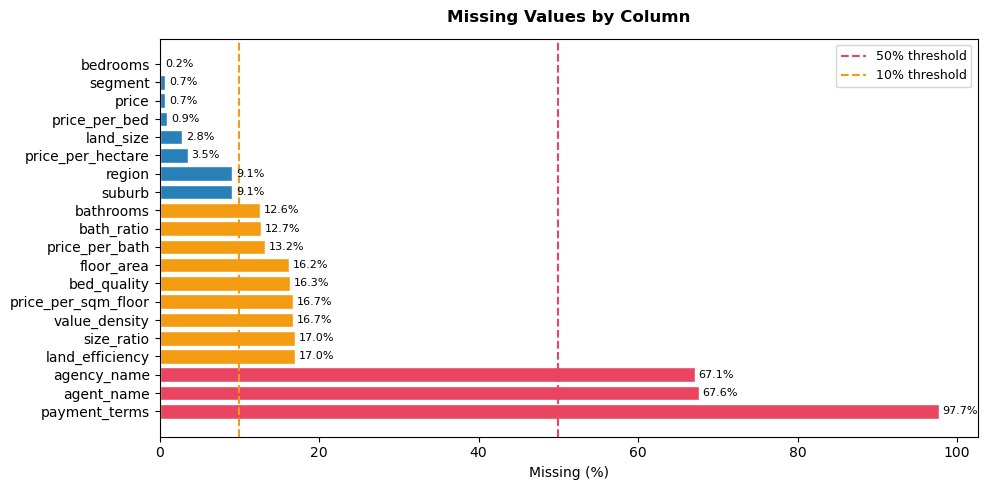

In [11]:
# ── Missing value bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors_bar = ['#E94560' if p > 50 else '#F39C12' if p > 10 else '#2980B9'
              for p in miss_df['Missing %']]

bars = ax.barh(miss_df.index, miss_df['Missing %'], color=colors_bar, edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column', fontweight='bold', pad=12)
ax.axvline(50, color='#E94560', linestyle='--', lw=1.5, label='50% threshold')
ax.axvline(10, color='#F39C12', linestyle='--', lw=1.5, label='10% threshold')

for bar, val in zip(bars, miss_df['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.legend(fontsize=9)
plt.tight_layout()
save('01_missing_values')


NameError: name 'save' is not defined

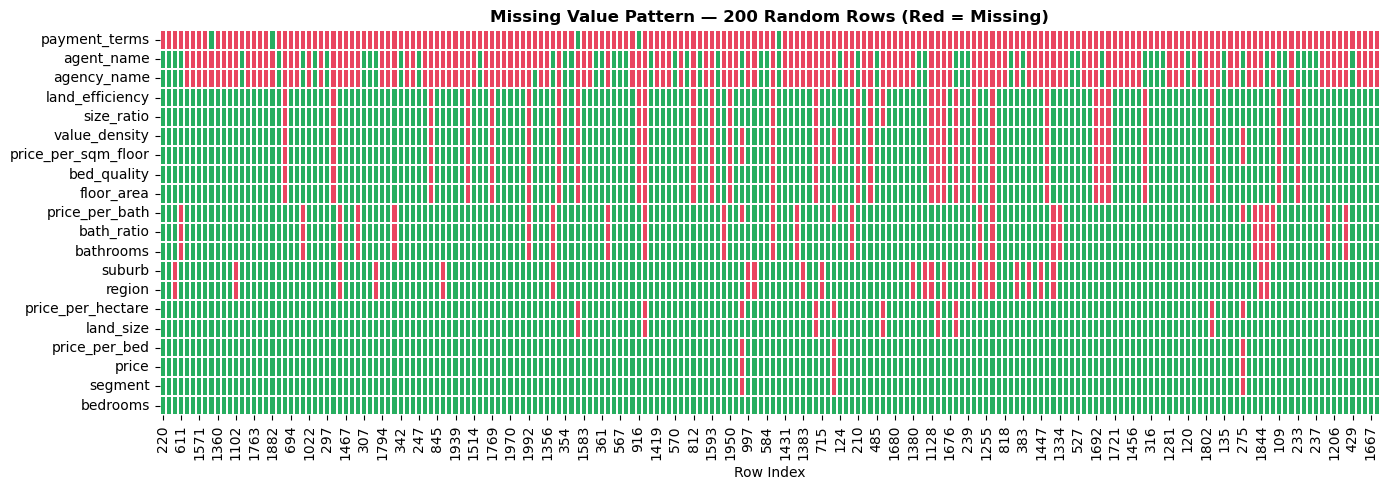

In [12]:
# ── Missing value heatmap (missingno-style) ─────────────────────────────────
cols_with_missing = miss_df.index.tolist()
sample = df[cols_with_missing].sample(min(200, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(sample.isnull().T, cbar=False, yticklabels=True,
            cmap=['#27AE60', '#E94560'], ax=ax, linewidths=0.1)
ax.set_title('Missing Value Pattern — 200 Random Rows (Red = Missing)', fontweight='bold')
ax.set_xlabel('Row Index')
plt.tight_layout()
save('02_missing_heatmap')


---
## 3. Price Distribution Analysis

The target variable. We examine raw and log distributions, skewness, and segment-level breakdowns.


In [13]:
# ── Drop rows with no price for price analysis ───────────────────────────────
df_price = df.dropna(subset=['price']).copy()
df_price['log_price'] = np.log1p(df_price['price'])

print(f'Records with price: {len(df_price):,}')
print()
print(df_price['price'].describe().apply(lambda x: f'${x:,.0f}'))
print(f'\nSkewness : {df_price["price"].skew():.2f}')
print(f'Kurtosis : {df_price["price"].kurt():.2f}')


Records with price: 2,022

count        $2,022
mean       $340,841
std        $419,357
min            $700
25%        $110,000
50%        $230,000
75%        $395,000
max      $7,500,000
Name: price, dtype: object

Skewness : 5.46
Kurtosis : 59.68


In [ ]:
# ── Price histogram — raw & log ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw
axes[0].hist(df_price['price']/1e6, bins=60, color='#1A1A2E', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Price (USD Millions)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution (Raw)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))

# Log
axes[1].hist(df_price['log_price'], bins=60, color='#E94560', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price Distribution (Log Scale)', fontweight='bold')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Target Variable: Property Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save('03_price_distribution')


In [ ]:
# ── Price by segment — violin plot ───────────────────────────────────────────
df_seg = df_price.dropna(subset=['segment'])
seg_order = ['Budget','Mid','Premium','Luxury']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin
parts = axes[0].violinplot(
    [df_seg[df_seg['segment']==s]['price'].values for s in seg_order],
    positions=range(len(seg_order)), showmedians=True, showextrema=True
)
for i, (pc, seg) in enumerate(zip(parts['bodies'], seg_order)):
    pc.set_facecolor(SEG_COLORS[seg])
    pc.set_alpha(0.75)
axes[0].set_xticks(range(len(seg_order)))
axes[0].set_xticklabels(seg_order)
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('Price Distribution by Segment', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

# Box (log scale)
for i, seg in enumerate(seg_order):
    data = df_seg[df_seg['segment']==seg]['log_price']
    bp = axes[1].boxplot(data, positions=[i], widths=0.5, patch_artist=True,
                         medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(SEG_COLORS[seg])
axes[1].set_xticks(range(len(seg_order)))
axes[1].set_xticklabels(seg_order)
axes[1].set_ylabel('log(1 + Price)')
axes[1].set_title('Log-Price Boxplot by Segment', fontweight='bold')

plt.tight_layout()
save('04_price_by_segment')


In [ ]:
# ── Segment distribution ─────────────────────────────────────────────────────
seg_counts = df_seg['segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar
axes[0].bar(seg_counts.index, seg_counts.values,
            color=[SEG_COLORS[s] for s in seg_counts.index], edgecolor='white')
axes[0].set_ylabel('Listing Count')
axes[0].set_title('Listings per Market Segment', fontweight='bold')
for i, (idx, val) in enumerate(seg_counts.items()):
    axes[0].text(i, val+5, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Pie
wedges, texts, autotexts = axes[1].pie(
    seg_counts.values, labels=seg_counts.index,
    colors=[SEG_COLORS[s] for s in seg_counts.index],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10})
axes[1].set_title('Market Segment Share', fontweight='bold')

plt.tight_layout()
save('05_segment_distribution')


In [ ]:
# ── IQR outlier detection ────────────────────────────────────────────────────
numeric_cols = ['price','floor_area','land_size','bedrooms','bathrooms',
                'price_per_sqm_floor','amenity_score','energy_score']

outlier_summary = []
for col in numeric_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lower) | (s > upper)).sum()
    outlier_summary.append({
        'Column': col, 'Q1': Q1, 'Q3': Q3,
        'IQR Lower': lower, 'IQR Upper': upper,
        'Outliers': n_out, 'Outlier %': round(n_out/len(s)*100,1)
    })

out_df = pd.DataFrame(outlier_summary)
display(out_df.style
    .background_gradient(subset=['Outlier %'], cmap='YlOrRd')
    .format({'Q1':'{:,.1f}','Q3':'{:,.1f}','IQR Lower':'{:,.1f}',
             'IQR Upper':'{:,.1f}','Outlier %':'{:.1f}%'})
)


In [ ]:
# ── Boxplots for key numeric features ────────────────────────────────────────
plot_cols = ['price','floor_area','land_size','bedrooms','bathrooms','price_per_sqm_floor']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    data = df[col].dropna()
    bp = axes[i].boxplot(data, patch_artist=True, vert=True,
                          medianprops=dict(color='white', linewidth=2.5))
    bp['boxes'][0].set_facecolor(PALETTE[i % len(PALETTE)])
    bp['boxes'][0].set_alpha(0.75)
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold')
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K' if x>1000 else f'{x:.0f}'))

plt.suptitle('Outlier Analysis — Key Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
save('06_outlier_boxplots')


---
## 5. Feature Distributions

Histograms for all key numeric features and bar charts for categorical columns.


In [ ]:
# ── Numeric feature histograms ───────────────────────────────────────────────
num_features = ['bedrooms','bathrooms','floor_area','land_size',
                'amenity_score','energy_score','maintenance_burden',
                'modern_amenities','data_quality_score']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color=PALETTE[i % len(PALETTE)],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold')
    axes[i].set_ylabel('Count')
    mean_val = data.mean()
    axes[i].axvline(mean_val, color='#E94560', linestyle='--', lw=1.5,
                    label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save('07_numeric_distributions')


In [ ]:
# ── Bedroom & bathroom counts ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color in zip(axes, ['bedrooms','bathrooms'], ['#1A1A2E','#E94560']):
    vc = df[col].dropna().value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel(col.title())
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {col.title()}', fontweight='bold')
    for j, (idx, val) in enumerate(vc.items()):
        ax.text(j, val+2, str(val), ha='center', fontsize=9)

plt.tight_layout()
save('08_bed_bath_distribution')


In [ ]:
# ── House type distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ht_counts = df['house_type'].value_counts().head(12)
ax.barh(ht_counts.index, ht_counts.values, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.set_xlabel('Count')
ax.set_title('Top 12 House Types', fontweight='bold')
for i, val in enumerate(ht_counts.values):
    ax.text(val+1, i, str(val), va='center', fontsize=9)

plt.tight_layout()
save('09_house_type_distribution')


---
## 6. Correlation Matrix

Pearson correlation across all numeric features — highlights multicollinearity and relationships with the target `price`.


In [ ]:
# ── Correlation matrix ───────────────────────────────────────────────────────
corr_cols = ['price','bedrooms','bathrooms','floor_area','land_size',
             'amenity_score','energy_score','maintenance_burden',
             'modern_amenities','bed_quality','bath_ratio',
             'land_efficiency','data_quality_score',
             'price_per_sqm_floor','value_density','size_ratio']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7},
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson r', 'shrink': 0.7})

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
save('10_correlation_matrix')


In [ ]:
# ── Top correlations with price ──────────────────────────────────────────────
price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors_corr = ['#E94560' if v > 0 else '#1A1A2E' for v in price_corr.values]
ax.barh(price_corr.index, price_corr.values, color=colors_corr, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Price')
ax.set_title('Feature Correlations with Price', fontweight='bold')

for i, val in enumerate(price_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
save('11_price_correlations')


In [ ]:
# ── Segment summary statistics ───────────────────────────────────────────────
seg_stats = df_seg.groupby('segment').agg(
    count=('price','count'),
    median_price=('price','median'),
    mean_price=('price','mean'),
    median_floor=('floor_area','median'),
    median_beds=('bedrooms','median'),
    avg_amenity=('amenity_score','mean'),
    avg_energy=('energy_score','mean'),
).round(0).reindex(seg_order)

print('Segment Summary Statistics')
display(seg_stats.style
    .background_gradient(subset=['median_price'], cmap='YlOrRd')
    .format({'median_price':'${:,.0f}','mean_price':'${:,.0f}',
             'median_floor':'{:.0f}m²','avg_amenity':'{:.1f}','avg_energy':'{:.1f}'})
)


In [ ]:
# ── Segment multi-metric comparison ──────────────────────────────────────────
metrics = ['median_price','median_floor','median_beds','avg_amenity','avg_energy']
labels  = ['Median Price ($)','Median Floor (m²)','Median Beds','Avg Amenity Score','Avg Energy Score']

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))

for ax, col, label in zip(axes, metrics, labels):
    vals = seg_stats[col]
    bars = ax.bar(seg_order, vals, color=[SEG_COLORS[s] for s in seg_order],
                  edgecolor='white', alpha=0.85)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xticklabels(seg_order, fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{val:,.0f}', ha='center', fontsize=8)

plt.suptitle('Segment Comparison Across Key Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
save('12_segment_comparison')


In [ ]:
# ── Scatter: price vs floor_area coloured by segment ─────────────────────────
df_scatter = df_seg.dropna(subset=['price','floor_area'])

fig, ax = plt.subplots(figsize=(11, 6))

for seg in seg_order:
    d = df_scatter[df_scatter['segment']==seg]
    ax.scatter(d['floor_area'], d['price']/1e3, label=seg,
               color=SEG_COLORS[seg], alpha=0.5, s=25, edgecolors='none')

ax.set_xlabel('Floor Area (m²)')
ax.set_ylabel('Price (USD Thousands)')
ax.set_title('Price vs Floor Area by Segment', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
ax.set_xlim(0, df_scatter['floor_area'].quantile(0.98))
ax.set_ylim(0, df_scatter['price'].quantile(0.98)/1e3)
ax.legend(title='Segment', fontsize=9)
plt.tight_layout()
save('13_price_vs_floor_area')


---
## 8. Amenity Analysis

Zimbabwe's infrastructure challenges make off-grid features (borehole, solar, inverter, generator) significant value drivers.


In [ ]:
# ── Amenity prevalence ────────────────────────────────────────────────────────
amenity_cols = ['has_pool','has_solar','has_borehole','has_garage',
                'has_garden','has_security','has_inverter','has_generator']
amenity_labels = ['Pool','Solar','Borehole','Garage','Garden','Security','Inverter','Generator']

prevalence = (df[amenity_cols].sum() / len(df) * 100).values
amenity_colors = ['#E94560','#F39C12','#27AE60','#1A1A2E',
                  '#27AE60','#8E44AD','#F39C12','#2980B9']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(amenity_labels, prevalence, color=amenity_colors, edgecolor='white', alpha=0.85)
axes[0].set_ylabel('% of Listings')
axes[0].set_title('Amenity Prevalence (% of All Listings)', fontweight='bold')
axes[0].set_xticklabels(amenity_labels, rotation=30, ha='right')
for bar, val in zip(bars, prevalence):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Radar-style stacked bar — amenity by segment
amenity_seg = df_seg.groupby('segment')[amenity_cols].mean() * 100
amenity_seg = amenity_seg.reindex(seg_order)
amenity_seg.columns = amenity_labels

bottom = np.zeros(len(seg_order))
bar_colors = amenity_colors
for j, (col, color) in enumerate(zip(amenity_labels, bar_colors)):
    axes[1].bar(seg_order, amenity_seg[col], bottom=bottom,
                label=col, color=color, alpha=0.8, edgecolor='white')
    bottom += amenity_seg[col].values

axes[1].set_ylabel('Cumulative Amenity % (stacked)')
axes[1].set_title('Amenity Prevalence by Segment (Stacked)', fontweight='bold')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
save('14_amenity_prevalence')


In [ ]:
# ── Amenity price premium ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(amenity_cols, amenity_labels)):
    ax = axes[i]
    has     = df_price[df_price[col]==True]['price']
    has_not = df_price[df_price[col]==False]['price']

    ax.boxplot([has_not, has], patch_artist=True,
               medianprops=dict(color='white', linewidth=2),
               labels=[f'No {label}', f'Has {label}'])
    ax.set_title(label, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

    # Annotate median difference
    diff = has.median() - has_not.median()
    sign = '+' if diff >= 0 else ''
    ax.text(0.5, 0.93, f'Median Δ: {sign}${diff/1e3:.0f}K',
            transform=ax.transAxes, ha='center', fontsize=8,
            color='#E94560' if diff > 0 else '#27AE60',
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

plt.suptitle('Price Premium by Amenity (Has vs Does Not Have)', fontsize=13, fontweight='bold')
plt.tight_layout()
save('15_amenity_price_premium')


In [ ]:
# ── Energy score vs price ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: energy_score vs price
es_data = df_price.dropna(subset=['energy_score'])
for seg in seg_order:
    d = es_data[es_data['segment']==seg]
    axes[0].scatter(d['energy_score'] + np.random.uniform(-0.1,0.1,len(d)),
                    d['price']/1e3, label=seg, color=SEG_COLORS[seg],
                    alpha=0.4, s=20, edgecolors='none')
axes[0].set_xlabel('Energy Score (0 = none, 4 = all off-grid features)')
axes[0].set_ylabel('Price (USD Thousands)')
axes[0].set_title('Energy Score vs Property Price', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
axes[0].legend(fontsize=8)

# Box: median price by energy score
energy_price = df_price.groupby('energy_score')['price'].median()
axes[1].bar(energy_price.index.astype(str), energy_price.values/1e3,
            color='#0F3460', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Energy Score')
axes[1].set_ylabel('Median Price (USD Thousands)')
axes[1].set_title('Median Price by Energy Score', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
for i, val in enumerate(energy_price.values):
    axes[1].text(i, val/1e3 + 2, f'${val/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
save('16_energy_score_vs_price')


---
## 9. Region & Suburb Analysis

Geographic price patterns across Zimbabwe's main urban centres.


In [ ]:
# ── Listings by region ───────────────────────────────────────────────────────
# Consolidate minor region variants
def clean_region(r):
    if pd.isna(r): return 'Unknown'
    r = str(r)
    if ',' in r: r = r.split(',')[-1].strip()
    return r

df['region_clean'] = df['region'].apply(clean_region)
region_counts = df['region_clean'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(region_counts.index, region_counts.values,
        color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.set_xlabel('Number of Listings')
ax.set_title('Listings by Region (Top 12)', fontweight='bold')
for i, val in enumerate(region_counts.values):
    ax.text(val+2, i, str(val), va='center', fontsize=9)
plt.tight_layout()
save('17_listings_by_region')


In [ ]:
# ── Median price by region ───────────────────────────────────────────────────
region_price = (df_price
    .assign(region_clean=df_price['region'].apply(clean_region))
    .groupby('region_clean')['price']
    .agg(['median','count'])
    .query('count >= 10')
    .sort_values('median', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 6))
colors_r = ['#E94560' if i < 3 else '#1A1A2E' for i in range(len(region_price))]
ax.barh(region_price.index, region_price['median']/1e3,
        color=colors_r, edgecolor='white', alpha=0.85)
ax.set_xlabel('Median Price (USD Thousands)')
ax.set_title('Median Property Price by Region (min 10 listings)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))

for i, (val, cnt) in enumerate(zip(region_price['median'], region_price['count'])):
    ax.text(val/1e3 + 1, i, f'${val/1e3:.0f}K (n={cnt})', va='center', fontsize=8)

plt.tight_layout()
save('18_price_by_region')


In [ ]:
# ── Region violin plot ────────────────────────────────────────────────────────
top_regions = region_price.head(8).index.tolist()
df_region_v = (df_price
    .assign(region_clean=df_price['region'].apply(clean_region))
    .query('region_clean in @top_regions')
)

fig, ax = plt.subplots(figsize=(13, 6))
region_data = [df_region_v[df_region_v['region_clean']==r]['price'].values
               for r in top_regions]
parts = ax.violinplot(region_data, positions=range(len(top_regions)),
                      showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i % len(PALETTE)])
    pc.set_alpha(0.7)
ax.set_xticks(range(len(top_regions)))
ax.set_xticklabels(top_regions, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Price (USD)')
ax.set_title('Price Distribution by Region (Top 8)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
plt.tight_layout()
save('19_region_violin')


In [ ]:
# ── Top 20 suburbs by median price ───────────────────────────────────────────
suburb_price = (df_price.dropna(subset=['suburb'])
    .groupby('suburb')['price']
    .agg(['median','count'])
    .query('count >= 5')
    .sort_values('median', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(11, 7))
gradient = [PALETTE[0] if i < 5 else PALETTE[2] for i in range(len(suburb_price))]
ax.barh(suburb_price.index, suburb_price['median']/1e3,
        color=gradient, edgecolor='white', alpha=0.85)
ax.set_xlabel('Median Price (USD Thousands)')
ax.set_title('Top 20 Suburbs by Median Property Price (min 5 listings)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))

for i, (val, cnt) in enumerate(zip(suburb_price['median'], suburb_price['count'])):
    ax.text(val/1e3 + 1, i, f'${val/1e3:.0f}K (n={cnt})', va='center', fontsize=8)

plt.tight_layout()
save('20_top_suburbs_by_price')


In [9]:
# ── Segment share by region (top 6 regions) ──────────────────────────────────
top6 = df_seg.assign(region_clean=df_seg['region'].apply(clean_region))
top6_regions = top6['region_clean'].value_counts().head(6).index.tolist()
seg_region = (top6[top6['region_clean'].isin(top6_regions)]
    .groupby(['region_clean','segment'])
    .size().unstack(fill_value=0)
    .reindex(columns=seg_order, fill_value=0)
)
seg_region_pct = seg_region.div(seg_region.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(seg_region_pct))
for seg in seg_order:
    vals = seg_region_pct[seg].values
    ax.bar(seg_region_pct.index, vals, bottom=bottom,
           label=seg, color=SEG_COLORS[seg], edgecolor='white', alpha=0.85)
    bottom += vals

ax.set_ylabel('Segment Share (%)')
ax.set_title('Market Segment Share by Region (Top 6 Regions)', fontweight='bold')
ax.set_xticklabels(seg_region_pct.index, rotation=20, ha='right')
ax.legend(title='Segment', fontsize=9, loc='upper right')
plt.tight_layout()
save('21_segment_by_region')


NameError: name 'df_seg' is not defined


## 10. Key Insights Summary

### 📊 Dataset

- **2,036 listings** across Zimbabwe; price range **$700 – $7.5M USD**
- **41 features** including 8 engineered score columns
- `payment_terms` (97.7% missing), `agent_name` (67.6%), `agency_name` (67.1%) — drop from modelling
- `floor_area` (16.2% missing), `bathrooms` (12.6%) — will require imputation in Phase 2

---

### 💰 Price

- Median price: **~$230,000** | Mean: **~$341,000** (right-skewed, log-transform recommended)
- Market is **well-balanced** across segments: Budget (25.3%) / Mid (25.4%) / Premium (24.4%) / Luxury (24.7%)
- Luxury median ≈ **8× Budget median** — large dynamic range

---

### 🌍 Geography

- **Harare North** dominates supply (33% of listings)
- **Harare North & East** command highest median prices
- **Bulawayo** has lower price levels but meaningful volume

---

### 🏡 Amenities

- **Garden** is near-universal (99.9% of listings)
- **Borehole** is the most common meaningful amenity (61.5%) — reflects infrastructure realities
- **Solar** (31.7%) and **Pool** (27.1%) carry visible price premiums
- **Inverter** (3.1%) and **Generator** (2.7%) are rare but concentrated in Luxury

---

### 🔑 Strongest Price Predictors (preview)

Based on correlation analysis:
1. `floor_area`
2. `bedrooms` / `bathrooms`
3. `amenity_score`
4. `energy_score`
5. `suburb_avg_price` (to be engineered in Phase 3)

---

### ✅ Phase 2 Actions

- Drop: `payment_terms`, `agent_name`, `agency_name`, `listing_url`
- Impute: `floor_area` (median by house_type+region), `bathrooms` (median by bedrooms)
- Cap price outliers at 99th percentile OR use log-transform as target
- Encode: `house_type`, `furnished`, `region`, `suburb` (target encoding for suburb)
- Remove listings where `data_quality_score < 3`


# ── Chart catalogue ──────────────────────────────────────────────────────────
import os
figs = sorted(os.listdir(FIG_DIR))
print(f'Total charts saved: {len(figs)}')
print()
for f in figs:
    path = os.path.join(FIG_DIR, f)
    size = os.path.getsize(path) / 1024
    print(f'  {f:<45} {size:>6.1f} KB')
